# Optimization

In [157]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from scipy.optimize import fmin, minimize

In [ ]:
# Load dataframes from binary files
fam = '03'
base_dir = r'D:\Entwicklungen\share\DataScienceProject'

all_data = {}
fam_dir = os.path.join(base_dir, fam, 'data-' + fam)
all_data[fam] = {}

ft_param_path = os.path.join(base_dir, 'Scripts', 'ft_files', str(fam) + '-feat-parameters.ft')
df_params = pd.read_feather(ft_param_path)

dump_dir = os.path.join(base_dir, 'Scripts', 'model_dumps')

In [185]:
# List of parameters
lst_param = df_params.columns.to_list()

lst_var = lst_param[1:4] + lst_param[5:7] + lst_param[8:24]
lst_nb_slots = [lst_param[4]] + [lst_param[7]]
lst_calc = lst_param[32:34]
lst_slot_class = lst_param[541:545]
lst_cols = lst_var + lst_calc + lst_slot_class

In [187]:
X = df_params[lst_cols]

In [121]:
# Get indices of Train-Test split
X_train, X_test, _, _ = train_test_split(X, X, test_size=0.2, random_state=55)
idx_train = X_train.index
idx_test = X_test.index

In [5]:
## Long displacements
# Target variable is the frequency of the longitudinal mode
y_nrdd = df_params['long_disp_nrdd']
y_nrdd_train = y_nrdd.loc[idx_train]
y_nrdd_test = y_nrdd.loc[idx_test]

In [6]:
## All Frequencies
# Target variables are frequencies of modes 50 to 85
lst_freq = lst_param[86:122]
Y_freq = df_params[lst_freq]
Y_freq_test = Y_freq.loc[idx_test]

In [7]:
## Long frequencies
y_longfreq = df_params['freq_long']
y_longfreq_test = y_longfreq.loc[idx_test]

Long displacements

In [8]:
transf_longdisp = pickle.load(open(os.path.join(dump_dir, '5_model_neuralnetw_tuned_transformer.pkl'), 'rb'))
pipe_tuned_longdisp = pickle.load(open(os.path.join(dump_dir, '5_model_neuralnetw_tuned_long_displacements.pkl'), 'rb'))

# Apply the power transformer to the NRDD variable
w_test = transf_longdisp.transform(y_nrdd_test.values.reshape(-1, 1))

print ('Score of the test set:', pipe_tuned_longdisp.score(X_test, w_test))

Score of the test set: 0.8550440040374117


All frequencies

In [9]:
pipe_tuned_allfreq = pickle.load(open(os.path.join(dump_dir, '4_model_lgbm_tuned_all_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_tuned_allfreq.score(X_test, Y_freq_test))

Score of the test set: 0.9975845732050838


Long frequency

In [10]:
pipe_tuned_longfreq = pickle.load(open(os.path.join(dump_dir, '4_model_lgbm_tuned_long_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_tuned_longfreq.score(X_test, y_longfreq_test))

Score of the test set: 0.9933359528253154


## Select the design point with the minimum cost

In [189]:
# ID 1647 for example
id_01 = y_nrdd.argmin()

print (id_01)
print(y_nrdd[[id_01]])

x_01 = X.loc[id_01].tolist()


1647
1647    1.291901
Name: long_disp_nrdd, dtype: float64


In [190]:
pd.DataFrame([x_01], columns=lst_cols)

,dim_x,dim_y,dim_z,slot_x_length,slot_x_distance,slot_z_length,slot_z_distance,chamfer_x_dim_y,chamfer_x_dim_z,chamfer_y_dim_x,...,cut_x_depth,cut_z_start,cut_z_end,cut_z_depth,seg_x_out,seg_z_out,slot_2-2,slot_3-2,slot_4-1,slot_4-2
0,173.11,122.93,240.8,74.851,48.149,77.13,53.2,4.1767,14.899,6.5351,...,0.3487,23.429,63.553,2.1605,48.1765,59.955,0.0,0.0,0.0,1.0


In [122]:
# Predictions of all models
def fea_pred(x):
    """
    x is list
    """

    x1 = pd.DataFrame([x], columns=lst_cols)

    # Longitudinal frequency
    freq_long = pipe_tuned_longfreq.predict(x1)[0]
    # All frequencies
    all_freq = pipe_tuned_allfreq.predict(x1)[0]
    # NRDD

    nrdd_transf = pipe_tuned_longdisp.predict(x1)
    nrdd = transf_longdisp.inverse_transform(nrdd_transf)

    # Position of the long. mode
    delta_f = abs(all_freq-freq_long)
    id_long = delta_f.argmin()

    return freq_long, all_freq, nrdd[0][0], id_long


In [ ]:
f_long, f_all, nrdd, idx = fea_pred(x_01) 
print (f_long, '\n', f_all, '\n', nrdd, '\n', idx)

19252.72063732115 
 [15260.27828227 15500.95683153 15599.54872674 15778.35841546
 15854.66728733 15908.47609677 15954.75439044 16023.66548765
 16033.27619731 16067.6331695  16142.872227   16403.63348786
 16443.07674304 16627.62247429 17097.06668295 17189.85312716
 17545.9414874  17679.7921517  17730.11106395 17902.47973162
 18414.82486541 18597.81419491 18662.80172641 18783.44023314
 18849.07959636 18873.26235529 19011.06742396 19091.63045942
 19279.80593494 19464.58127239 20375.83518321 20571.33844436
 20654.41997341 21226.59906278 22011.44300131 22064.09764223] 
 1.6892109 
 28


In [143]:
weights = {'f_long': 1/0.0006440096234678033, 'nrdd': 1/5.806682727065343, 'f_all': 1/0.12581713798880445}

In [191]:
# cost functions
def f_cost(x, weights):
    weight_f_long = weights['f_long']
    weight_nrdd = weights['nrdd']
    weight_f_all = weights['f_all']

    f_long, f_all, nrdd, idx = fea_pred(x) 

    cost_f_long = weight_f_long * ((f_long-20e3)/20e3)**2
    cost_nrdd = weight_nrdd * nrdd

    f0 = f_all[idx]
    cost_f_below = (1/(f_all[idx-1]-f0))**2
    cost_f_above = (1/(f_all[idx+1]-f0))**2
    cost_f_all = weight_f_all * (cost_f_below + cost_f_above)

    return {'cost_f_long': cost_f_long, 'cost_nrdd': cost_nrdd, 'cost_f_all': cost_f_all}

In [218]:
f_cost(x_01, weights) 

{'cost_f_long': 2.1677721323431,
 'cost_nrdd': 0.2909080745621086,
 'cost_f_all': 0.0004572517349875102}

In [ ]:
# Calculate the cost functions for all design points
# then calculate the mean values in order to determine the weights

In [ ]:
# df_params['cost_f_long'] = df_params.apply(lambda row: f_cost(row.tolist())['cost_f_long'], axis=1)

In [146]:
for id in df_params.index:
    print ('Index: ', id, ' / ', len(df_params.index)-1)
    lst_row = df_params.loc[id, lst_cols].tolist()
    costs = f_cost(lst_row, weights)
    
    df_params.loc[id, 'cost_f_long'] = costs['cost_f_long']
    df_params.loc[id, 'cost_nrdd'] = costs['cost_nrdd']
    df_params.loc[id, 'cost_f_all'] = costs['cost_f_all']

Index:  0  /  7989
Index:  1  /  7989
Index:  2  /  7989
Index:  3  /  7989
Index:  4  /  7989
Index:  5  /  7989
Index:  6  /  7989
Index:  7  /  7989
Index:  8  /  7989
Index:  9  /  7989
Index:  10  /  7989
Index:  11  /  7989
Index:  12  /  7989
Index:  13  /  7989
Index:  14  /  7989
Index:  15  /  7989
Index:  16  /  7989
Index:  17  /  7989
Index:  18  /  7989
Index:  19  /  7989
Index:  20  /  7989
Index:  21  /  7989
Index:  22  /  7989
Index:  23  /  7989
Index:  24  /  7989
Index:  25  /  7989
Index:  26  /  7989
Index:  27  /  7989
Index:  28  /  7989
Index:  29  /  7989
Index:  30  /  7989
Index:  31  /  7989
Index:  32  /  7989
Index:  33  /  7989
Index:  34  /  7989
Index:  35  /  7989
Index:  36  /  7989
Index:  37  /  7989
Index:  38  /  7989
Index:  39  /  7989
Index:  40  /  7989
Index:  41  /  7989
Index:  42  /  7989
Index:  43  /  7989
Index:  44  /  7989
Index:  45  /  7989
Index:  46  /  7989
Index:  47  /  7989
Index:  48  /  7989
Index:  49  /  7989
Index:  50

In [147]:
print ('mean(cost_f_long):', df_params['cost_f_long'].mean())
print ('mean(cost_nrdd):', df_params['cost_nrdd'].mean())
print ('mean(cost_f_all):', df_params['cost_f_all'].mean())

mean(cost_f_long): 1.0
mean(cost_nrdd): 1.0
mean(cost_f_all): 1.0000000000000002


In [148]:
df_params

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,disp_long_399,sum_sensi,coupling_long,slot_2-2,slot_3-2,slot_4-1,slot_4-2,cost_f_long,cost_nrdd,cost_f_all
0,1001,175.06,121.95,240.31,4,75.993,43.235,2,78.219,59.508,...,0.151599,3.405414e-16,0.960466,0,0,0,1,2.325274,0.790851,0.001377
1,1002,173.45,122.77,238.13,4,81.168,45.859,2,78.924,57.208,...,0.143682,5.401730e-17,0.956635,0,0,0,1,1.445190,0.862617,0.000067
2,1003,175.85,116.71,238.10,4,77.532,45.260,2,80.099,49.215,...,0.284010,2.678586e-18,0.986845,0,0,0,1,0.028583,0.457030,0.000214
3,1004,173.51,116.37,238.30,4,82.428,51.007,2,74.757,50.840,...,0.186770,8.933099e-18,0.967459,0,0,0,1,0.185949,0.712492,0.000088
4,1005,175.60,118.72,241.04,4,76.576,45.981,2,78.773,64.702,...,0.293833,8.025438e-18,0.991598,0,0,0,1,0.121666,0.374403,0.000124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7985,11995,175.18,119.50,239.53,2,78.314,80.925,2,77.038,54.535,...,0.175034,1.445371e-17,0.960601,1,0,0,0,0.496236,0.811158,0.000278
7986,11996,176.27,117.29,240.59,2,77.933,71.773,2,79.789,63.279,...,0.332184,3.340311e-16,0.888124,1,0,0,0,1.849329,1.576772,0.001661
7987,11997,174.01,117.81,239.26,2,80.402,81.905,2,79.398,60.146,...,0.266484,3.313740e-18,0.964230,1,0,0,0,1.503830,0.596901,0.003135
7988,11998,174.61,119.50,239.41,2,74.848,74.107,2,74.870,57.402,...,-0.236469,1.190454e-15,0.606705,1,0,0,0,0.019166,2.671387,0.000251


In [ ]:
# Find the design point x_0 with the minimal cost function
# Note the slot class
df_params['cost'] = df_params['cost_f_long'] + df_params['cost_nrdd'] + df_params['cost_f_all']

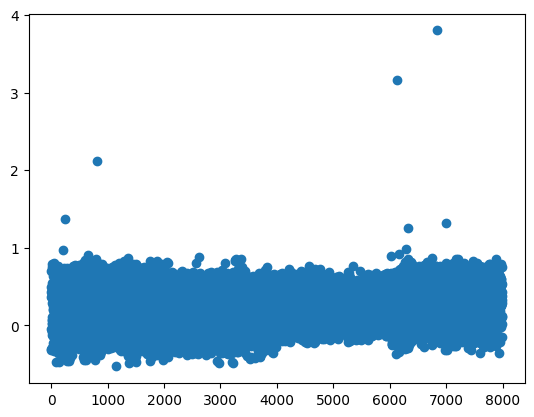

In [162]:
plt.scatter(range(len(df_params)), np.log10(df_params['cost']))

In [171]:
idx_0 = df_params['cost'].idxmin()
print ('Index:', idx_0)

Index: 1152


In [172]:
df_params.loc[[idx_0]]

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,sum_sensi,coupling_long,slot_2-2,slot_3-2,slot_4-1,slot_4-2,cost_f_long,cost_nrdd,cost_f_all,cost
1152,2153,175.51,119.21,241.21,4,75.641,53.089,2,76.463,49.445,...,4.342749e-18,0.991657,0,0,0,1,0.009187,0.286449,0.000326,0.295962


In [231]:
xvar_0 = df_params.loc[idx_0, lst_var].tolist()
xvar_0

[175.51,
 119.21,
 241.21,
 75.641,
 53.089,
 76.463,
 49.445,
 11.367,
 8.8571,
 10.448,
 6.0016,
 7.8842,
 13.908,
 0.76625,
 0.23867,
 30.419,
 70.146,
 4.489,
 29.596,
 63.282,
 1.3673]

In [217]:
df_params.loc[idx_0, lst_cols]

dim_x               175.51
dim_y               119.21
dim_z               241.21
slot_x_length       75.641
slot_x_distance     53.089
slot_z_length       76.463
slot_z_distance     49.445
chamfer_x_dim_y     11.367
chamfer_x_dim_z     8.8571
chamfer_y_dim_x     10.448
chamfer_y_dim_z     6.0016
chamfer_z_dim_x     7.8842
chamfer_z_dim_y     13.908
elefoot_x          0.76625
elefoot_z          0.23867
cut_x_start         30.419
cut_x_end           70.146
cut_x_depth          4.489
cut_z_start         29.596
cut_z_end           63.282
cut_z_depth         1.3673
seg_x_out          40.9715
seg_z_out          63.0325
slot_2-2                 0
slot_3-2                 0
slot_4-1                 0
slot_4-2                 1
Name: 1152, dtype: object

In [168]:
# Definitions of the bounds
var_bounds = [(173, 177), (115, 125), (238, 242), (74, 83), (41, 55), (74, 83), (49, 67), (0.1, 20), (0.1, 20), (0.1, 20), (0.1, 20),
          (0.1, 20), (0.1, 20), (0.1, 5), (0.1, 5), (20, 60), (60, 100), (0.1, 5), (20, 45), (45, 70), (0.1, 5)]

In [227]:
# function x_var --> x
def f_xvar2x(xvar, nb_slots_x, nb_slots_z):
    #nb_slots_x = 4
    #nb_slots_z = 2

    dim_z = xvar[2]
    dim_x = xvar[0]
    slot_x_distance = xvar[4]
    slot_z_distance = xvar[6]
    seg_x_out = (dim_z-(nb_slots_x-1)*slot_x_distance)/2
    seg_z_out = (dim_x-(nb_slots_z-1)*slot_z_distance)/2
    x_calc = [seg_x_out, seg_z_out]

    if (nb_slots_x == 2) & (nb_slots_z == 2):
        x_slot_classes = [1, 0, 0, 0]
    if (nb_slots_x == 3) & (nb_slots_z == 2):
        x_slot_classes = [0, 1, 0, 0]
    if (nb_slots_x == 4) & (nb_slots_z == 1):
        x_slot_classes = [0, 0, 1, 0]
    if (nb_slots_x == 4) & (nb_slots_z == 2):
        x_slot_classes = [0, 0, 0, 1]

    return xvar + x_calc + x_slot_classes


In [232]:
f_xvar2x(xvar_0, 4, 2)

[175.51,
 119.21,
 241.21,
 75.641,
 53.089,
 76.463,
 49.445,
 11.367,
 8.8571,
 10.448,
 6.0016,
 7.8842,
 13.908,
 0.76625,
 0.23867,
 30.419,
 70.146,
 4.489,
 29.596,
 63.282,
 1.3673,
 40.971500000000006,
 63.0325,
 0,
 0,
 0,
 1]

In [229]:
# cost functions
def f_cost2(xvar, weights):
    weight_f_long = weights['f_long']
    weight_nrdd = weights['nrdd']
    weight_f_all = weights['f_all']

    x = f_xvar2x(xvar, 4, 2)

    f_long, f_all, nrdd, idx = fea_pred(x) 

    cost_f_long = weight_f_long * ((f_long-20e3)/20e3)**2
    cost_nrdd = weight_nrdd * nrdd

    f0 = f_all[idx]
    cost_f_below = (1/(f_all[idx-1]-f0))**2
    cost_f_above = (1/(f_all[idx+1]-f0))**2
    cost_f_all = weight_f_all * (cost_f_below + cost_f_above)

    return {'cost_f_long': cost_f_long, 'cost_nrdd': cost_nrdd, 'cost_f_all': cost_f_all}

In [230]:
res = minimize(f_cost2, xvar_0, args=(weights), method='L-BFGS-B', bounds=var_bounds)

ValueError: operands could not be broadcast together with shapes (21,) (2,) 